In [181]:
import pandas as pd

df_User =pd.read_csv("1.csv")
df_Item =pd.read_csv("2.csv")
df_Sale =pd.read_csv("3.csv")
df_Sale

,BID_MONTH_WIN,SIT_SITE_ID,ITE_ITEM_ID,TIM_DAY_WINNING_DATE,CUS_CUST_ID_SEL,CAT_CATEG_ID,BID_BASE_CURRENT_PRICE,BID_QUANTITY_OK,ORD_ORDER_ID,ITE_SHIPPING_MODE_ID
0,202008,MLB,1507897050,2020/8/4,435860284,73364,20.35,1,2.610427e+09,me1
1,202008,MLB,1507897050,2020/8/12,435860284,73364,23.29,1,2.628831e+09,me1
2,202008,MLB,1507897050,2020/8/1,435860284,73364,20.43,1,2.604974e+09,me1
3,202008,MLB,1396034502,2020/8/11,435860284,7457,23.79,1,2.624761e+09,me1
4,202008,MLB,1507897050,2020/8/14,435860284,73364,23.02,1,2.633171e+09,me1
...,...,...,...,...,...,...,...,...,...,...
26264,202008,MLC,542347143,2020/8/31,435860518,416771,12.49,1,4.014934e+09,me1
26265,202010,MLM,723857586,2020/10/14,459687369,7857,71.68,1,4.096872e+09,me2
26266,202009,MLM,750120443,2020/9/14,435857820,9883,22.61,1,4.038990e+09,me1
26267,202010,MLB,1311106209,2020/10/27,435860284,108704,20.14,1,4.121835e+09,me1


# 第二问

In [215]:
df_User =pd.read_csv("1.csv")
df_Item =pd.read_csv("2.csv")
df_Sale =pd.read_csv("3.csv")

df_Sale = pd.merge(df_Sale,df_Item[["ITE_ITEM_ID","ITE_ITEM_ID_PARENT_CBT"]])
df_Sale

,BID_MONTH_WIN,SIT_SITE_ID,ITE_ITEM_ID,TIM_DAY_WINNING_DATE,CUS_CUST_ID_SEL,CAT_CATEG_ID,BID_BASE_CURRENT_PRICE,BID_QUANTITY_OK,ORD_ORDER_ID,ITE_SHIPPING_MODE_ID,ITE_ITEM_ID_PARENT_CBT
0,202008,MLB,1507897050,2020/8/4,435860284,73364,20.35,1,2.610427e+09,me1,920187526
1,202008,MLB,1507897050,2020/8/12,435860284,73364,23.29,1,2.628831e+09,me1,920187526
2,202008,MLB,1507897050,2020/8/1,435860284,73364,20.43,1,2.604974e+09,me1,920187526
3,202008,MLB,1396034502,2020/8/11,435860284,7457,23.79,1,2.624761e+09,me1,920163754
4,202008,MLB,1507897050,2020/8/14,435860284,73364,23.02,1,2.633171e+09,me1,920187526
...,...,...,...,...,...,...,...,...,...,...,...
26264,202008,MLC,542347143,2020/8/31,435860518,416771,12.49,1,4.014934e+09,me1,947075433
26265,202010,MLM,723857586,2020/10/14,459687369,7857,71.68,1,4.096872e+09,me2,920033405
26266,202009,MLM,750120443,2020/9/14,435857820,9883,22.61,1,4.038990e+09,me1,920159727
26267,202010,MLB,1311106209,2020/10/27,435860284,108704,20.14,1,4.121835e+09,me1,920130582


In [272]:
# ITE_ITEM_ID,SIT_SITE_ID,CUS_CUST_ID,DATE_CREATED,CUS_CUST_ID_PARENT_CBT,ITE_STATUS,ITE_ITEM_ID_PARENT_CBT

# 计算GMV
df_Sale_CL = df_Sale[
    (df_Sale['SIT_SITE_ID'] == 'MLC   ')
]

df_Sale_MX = df_Sale[
    (df_Sale['SIT_SITE_ID'] == 'MLM   ')
]

df_Sale_CL_ITE = df_Sale_CL.groupby(['ITE_ITEM_ID_PARENT_CBT','CUS_CUST_ID_SEL']).apply(
    lambda x: pd.Series({
        'GMV': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum(),
        'Avg_Price': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum()/ (x['BID_QUANTITY_OK']).sum(),
        'Count': (x['BID_QUANTITY_OK']).sum(),
        'BID_MONTH_WIN':x['BID_MONTH_WIN'].iloc[-1],
        'ITE_ITEM_ID':x['ITE_ITEM_ID'].iloc[-1],
        'CAT_CATEG_ID':x["CAT_CATEG_ID"].iloc[-1],
        # 'CUS_CUST_ID_SEL':x['CUS_CUST_ID_SEL'].iloc[-1]
        
    })
).reset_index()

df_Sale_MX_ITE = df_Sale_MX.groupby(['ITE_ITEM_ID_PARENT_CBT','CUS_CUST_ID_SEL']).apply(
    lambda x: pd.Series({
        'GMV': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum(),
        'Avg_Price': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum()/ (x['BID_QUANTITY_OK']).sum(),
        'Count': (x['BID_QUANTITY_OK']).sum(),
        'BID_MONTH_WIN':x['BID_MONTH_WIN'].iloc[-1],
        'ITE_ITEM_ID':x['ITE_ITEM_ID'].iloc[-1],
        'CAT_CATEG_ID':x["CAT_CATEG_ID"].iloc[-1],
        # 'CUS_CUST_ID_SEL':x['CUS_CUST_ID_SEL'].unique()
        
    })
).reset_index()
df_Sale_CL_ITE

C:\Users\59680\AppData\Local\Temp\ipykernel_36636\322604891.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_Sale_CL_ITE = df_Sale_CL.groupby(['ITE_ITEM_ID_PARENT_CBT','CUS_CUST_ID_SEL']).apply(
C:\Users\59680\AppData\Local\Temp\ipykernel_36636\322604891.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_Sale_MX_ITE = df_Sale_MX.groupby(['ITE_ITEM_ID_PARENT_CBT','CUS_CUST_ID_SEL']).apply(


,ITE_ITEM_ID_PARENT_CBT,CUS_CUST_ID_SEL,GMV,Avg_Price,Count,BID_MONTH_WIN,ITE_ITEM_ID,CAT_CATEG_ID
0,919998458,435860518,36.38,7.276,5.0,202010.0,496623891.0,1341.0
1,919998703,435860518,6.62,6.620,1.0,202008.0,496338220.0,1022.0
2,920012806,435860518,6.38,6.380,1.0,202010.0,496545954.0,440679.0
3,920013141,435860518,243.90,243.900,1.0,202010.0,496366087.0,436959.0
4,920017206,435860518,10.02,1.670,6.0,202009.0,496654240.0,162499.0
...,...,...,...,...,...,...,...,...
469,954940478,435860518,6.98,6.980,1.0,202010.0,550568562.0,432003.0
470,955947478,435860518,6.02,6.020,1.0,202010.0,551350283.0,116343.0
471,956361138,435860518,139.27,27.854,5.0,202010.0,551602110.0,116343.0
472,956917260,435860518,3.56,3.560,1.0,202010.0,552044911.0,82252.0


In [279]:
df_Sale_CL["CUS_CUST_ID_SEL"].unique()

array([435860518], dtype=int64)

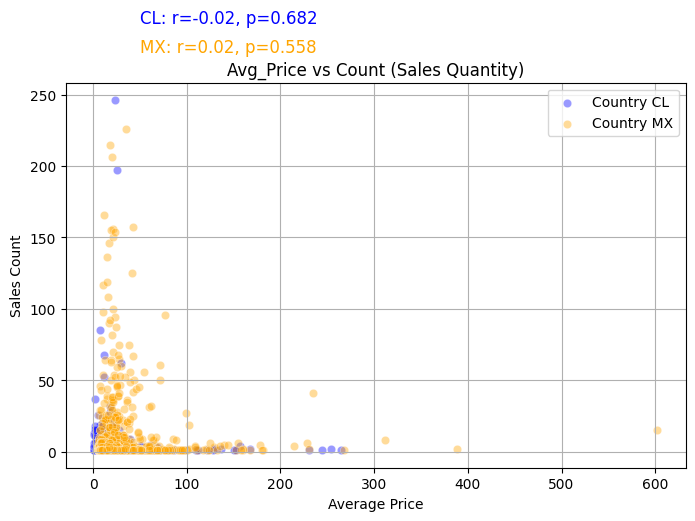

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, linregress

# 假设 df_Sale_CL_ITE 和 df_Sale_MX_ITE 分别是两个国家的销售数据


# 计算皮尔逊相关系数
corr_CL, pval_CL = pearsonr(df_Sale_CL_ITE['Avg_Price'], df_Sale_CL_ITE['Count'])
corr_MX, pval_MX = pearsonr(df_Sale_MX_ITE['Avg_Price'], df_Sale_MX_ITE['Count'])

# 计算回归直线
slope_CL, intercept_CL, _, _, _ = linregress(df_Sale_CL_ITE['Avg_Price'], df_Sale_CL_ITE['Count'])
slope_MX, intercept_MX, _, _, _ = linregress(df_Sale_MX_ITE['Avg_Price'], df_Sale_MX_ITE['Count'])

# 绘制散点图
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Avg_Price', y='Count', data=df_Sale_CL_ITE, color="blue", alpha=0.4, label="Country CL")
sns.scatterplot(x='Avg_Price', y='Count', data=df_Sale_MX_ITE, color="orange", alpha=0.4, label="Country MX")

# 添加回归直线
# x_vals = np.linspace(5, 50, 100)
# plt.plot(x_vals, slope_CL * x_vals + intercept_CL, color='blue', linestyle="dashed", label=f"CL Regression (r={corr_CL:.2f})")
# plt.plot(x_vals, slope_MX * x_vals + intercept_MX, color='orange', linestyle="dashed", label=f"MX Regression (r={corr_MX:.2f})")

# 标注相关系数
plt.text(50, 300, f"CL: r={corr_CL:.2f}, p={pval_CL:.3f}", color="blue", fontsize=12)
plt.text(50, 280, f"MX: r={corr_MX:.2f}, p={pval_MX:.3f}", color="orange", fontsize=12)

plt.title('Avg_Price vs Count (Sales Quantity)')
plt.xlabel('Average Price')
plt.ylabel('Sales Count')
plt.legend()
plt.grid(True)
plt.savefig("price_vs_count_comparison.jpg")
plt.show()


In [282]:
import numpy as np
import pandas as pd

# 生成价格列表，（价格关于数量进行重复，比如在5块卖了3个，就是 5，5，5）
price_list_CL = np.repeat(df_Sale_CL_ITE['Avg_Price'], df_Sale_CL_ITE['Count']).tolist()
price_list_MX = np.repeat(df_Sale_MX_ITE['Avg_Price'], df_Sale_MX_ITE['Count']).tolist()

print("Country CL price list:", price_list_CL)
print("Country MX price list:", price_list_MX)


Country CL price list: [7.275999999999999, 7.275999999999999, 7.275999999999999, 7.275999999999999, 7.275999999999999, 6.62, 6.38, 243.9, 1.67, 1.67, 1.67, 1.67, 1.67, 1.67, 5.89, 4.43, 52.25, 11.23, 11.23, 51.26, 26.65, 26.65, 4.11, 4.11, 3.96, 3.96, 3.96, 3.96, 3.96, 9.93, 17.18, 5.47, 5.47, 5.47, 12.58, 12.58, 65.84, 3.72, 6.65, 7.233333333333333, 7.233333333333333, 7.233333333333333, 121.35, 16.142, 16.142, 16.142, 16.142, 16.142, 31.85, 11.121666666666668, 11.121666666666668, 11.121666666666668, 11.121666666666668, 11.121666666666668, 11.121666666666668, 60.496, 60.496, 60.496, 60.496, 60.496, 264.51, 10.17, 5.452500000000001, 5.452500000000001, 5.452500000000001, 5.452500000000001, 11.67, 17.905, 17.905, 16.74, 12.23, 5.57, 5.57, 6.6, 2.91, 2.91, 2.91, 6.58, 13.68, 13.68, 18.439999999999998, 18.439999999999998, 14.08, 14.08, 3.6, 15.29, 11.25, 23.95, 23.95, 15.07, 15.07, 15.07, 35.72, 136.565, 136.565, 38.88, 38.88, 11.03, 230.66, 2.412, 2.412, 2.412, 2.412, 2.412, 2.35, 40.73, 1

In [283]:
len(price_list_MX)

9583

C:\Users\59680\AppData\Local\Temp\ipykernel_36636\2945844467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y='Price', data=df_combined, palette=['blue', 'orange'])


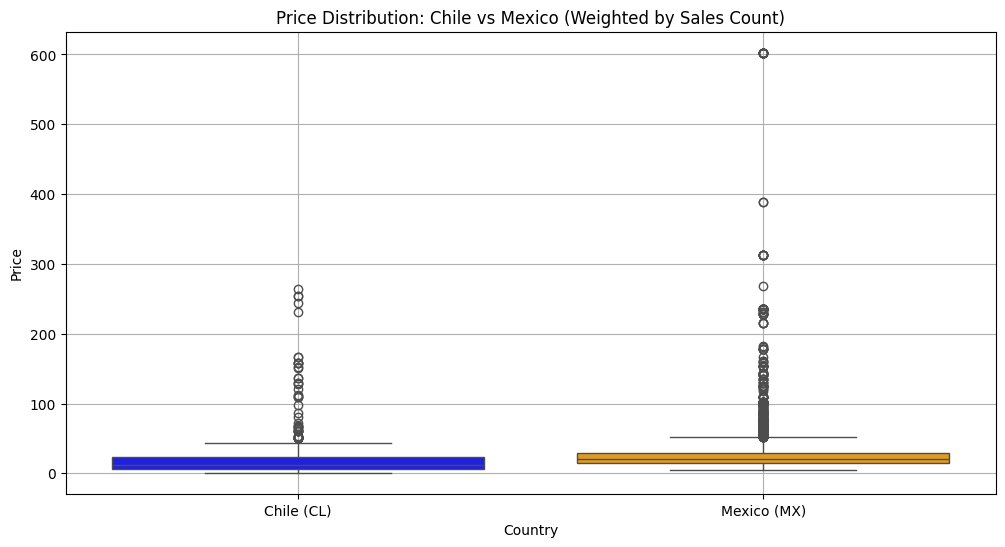

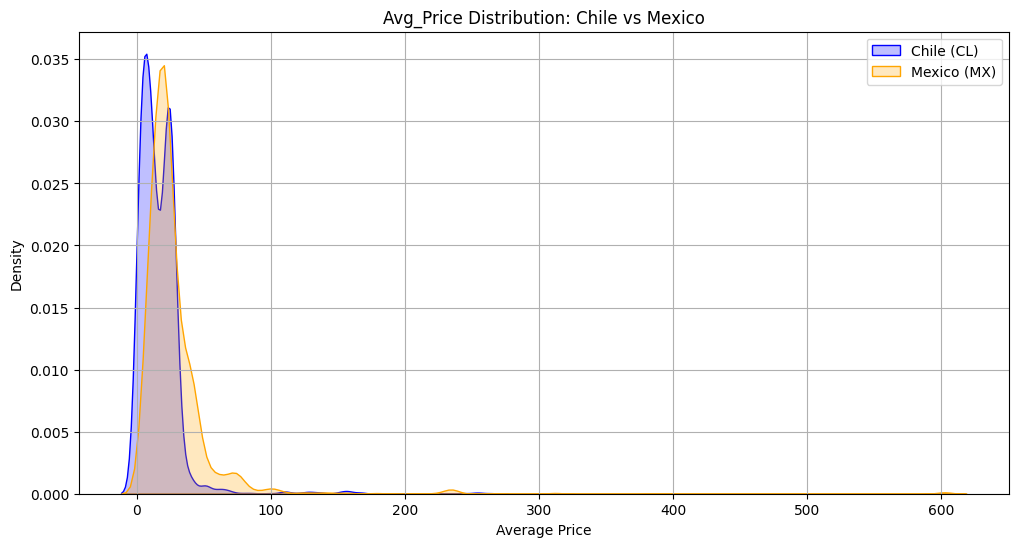

Avg_Price T-test: t-statistic = -14.50, p-value = 0.0000


In [284]:
# 创建新的 DataFrame 以适配 Seaborn
df_price_CL = pd.DataFrame({'Price': price_list_CL, 'Country': 'Chile (CL)'})
df_price_MX = pd.DataFrame({'Price': price_list_MX, 'Country': 'Mexico (MX)'})

# 合并数据
df_combined = pd.concat([df_price_CL, df_price_MX], ignore_index=True)

# 绘制箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='Price', data=df_combined, palette=['blue', 'orange'])
plt.title('Price Distribution: Chile vs Mexico (Weighted by Sales Count)')
plt.xlabel('Country')
plt.ylabel('Price')
plt.grid(True)
plt.savefig("CL_MX_price_distribution_boxplot.jpg")
plt.show()

# 绘制 Avg_Price 的 KDE 图
plt.figure(figsize=(12, 6))
sns.kdeplot(price_list_CL, color='blue', label='Chile (CL)', fill=True)
sns.kdeplot(price_list_MX, color='orange', label='Mexico (MX)', fill=True)
plt.title('Avg_Price Distribution: Chile vs Mexico')
plt.xlabel('Average Price')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.savefig("CL_MX_avg_price_kde.jpg")
plt.show()

from scipy.stats import ttest_ind, mannwhitneyu

# 对 Avg_Price 列表 进行 t 检验
t_stat_avg_price, p_value_avg_price = ttest_ind(price_list_CL, price_list_MX)

print(f'Avg_Price T-test: t-statistic = {t_stat_avg_price:.2f}, p-value = {p_value_avg_price:.4f}')
# print(f'Count Mann-Whitney U test: U-statistic = {u_stat_count:.2f}, p-value = {p_value_count:.4f}')


## 在智利和墨西哥均售卖的物品

In [280]:
import pandas as pd
# 合并两个表
merged = df_Sale_CL_ITE.merge(df_Sale_MX_ITE, on="ITE_ITEM_ID_PARENT_CBT", suffixes=("_CL", "_MX"))
# 计算差异
merged["Diff_Price"] = merged["Avg_Price_CL"] - merged["Avg_Price_MX"]
merged["Diff_Count"] = merged["Count_CL"] - merged["Count_MX"]
merged.sort_values(by="Diff_Price",ascending=False)

,ITE_ITEM_ID_PARENT_CBT,CUS_CUST_ID_SEL_CL,GMV_CL,Avg_Price_CL,Count_CL,BID_MONTH_WIN_CL,ITE_ITEM_ID_CL,CAT_CATEG_ID_CL,CUS_CUST_ID_SEL_MX,GMV_MX,Avg_Price_MX,Count_MX,BID_MONTH_WIN_MX,ITE_ITEM_ID_MX,CAT_CATEG_ID_MX,Diff_Price,Diff_Count
10,920139811,435860518,508.48,254.240000,2.0,202008.0,511725209.0,180993.0,435857820,9631.47,234.913902,41.0,202010.0,733476754.0,120568.0,19.326098,-39.0
2,920070747,435860518,31.85,31.850000,1.0,202009.0,496676724.0,429014.0,459687369,69.10,23.033333,3.0,202010.0,723857610.0,429016.0,8.816667,-2.0
0,920028571,435860518,53.30,26.650000,2.0,202009.0,496670147.0,175495.0,435857820,52.62,26.310000,2.0,202008.0,697452728.0,103745.0,0.340000,0.0
16,920186421,435860518,90.51,22.627500,4.0,202010.0,529665511.0,417755.0,459687369,577.61,23.104400,25.0,202009.0,780720599.0,194390.0,-0.476900,-21.0
9,920136766,435860518,70.50,35.250000,2.0,202010.0,499263094.0,116538.0,459687369,2892.92,38.572267,75.0,202010.0,723857479.0,126793.0,-3.322267,-73.0
5,920102546,435860518,35.81,17.905000,2.0,202010.0,496670876.0,1667.0,435857820,22.17,22.170000,1.0,202008.0,697453170.0,1667.0,-4.265000,1.0
1,920060933,435860518,6.65,6.650000,1.0,202009.0,496679085.0,180894.0,435857820,11.01,11.010000,1.0,202008.0,697458726.0,172007.0,-4.360000,0.0
34,944669783,435860518,4.84,4.840000,1.0,202010.0,538978162.0,431603.0,435857820,18.97,9.485000,2.0,202010.0,799589017.0,4605.0,-4.645000,-1.0
8,920134443,435860518,2.40,2.400000,1.0,202010.0,502828108.0,1436.0,435857820,14.26,7.130000,2.0,202009.0,712333564.0,1436.0,-4.730000,-1.0
21,939816307,435860518,45.14,22.570000,2.0,202009.0,534070492.0,430901.0,435857820,27.90,27.900000,1.0,202010.0,789078529.0,5015.0,-5.330000,1.0


### 从上表中发现，在智利和墨西哥同时售卖并产生交易的45项产品中，实际在智利卖出去的货品仅有3/45项是比墨西哥价格更贵，其余都是比墨西哥价格更便宜的。

# 无关

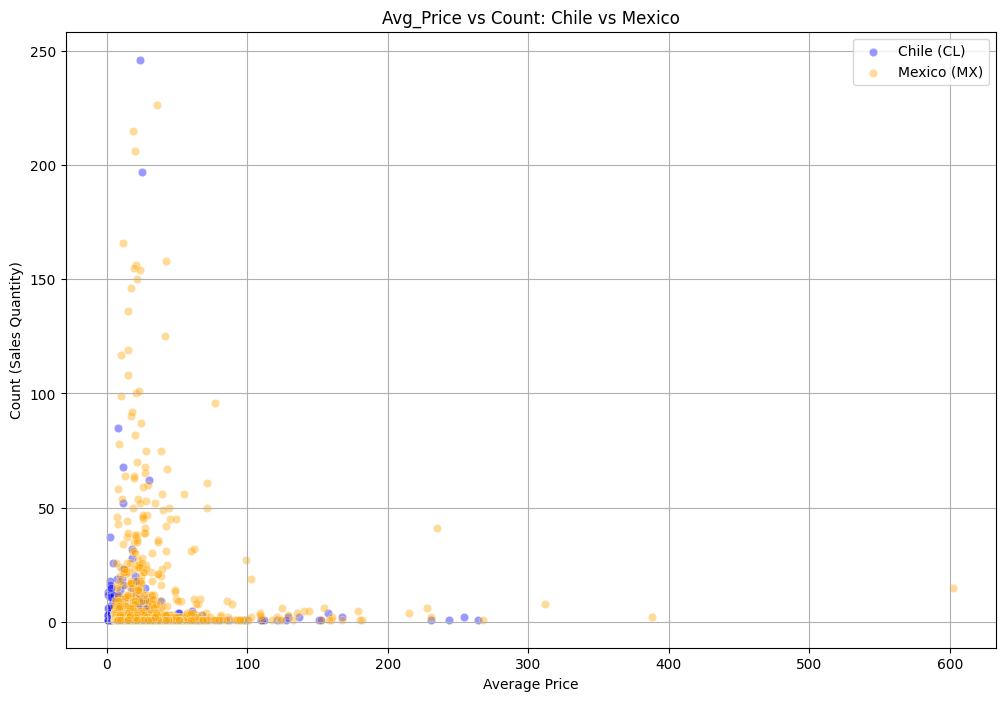

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制散点图
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Avg_Price', y='Count', data=df_Sale_CL_ITE, color="blue", alpha=0.4, label='Chile (CL)')
sns.scatterplot(x='Avg_Price', y='Count', data=df_Sale_MX_ITE, color="orange", alpha=0.4, label='Mexico (MX)')
plt.title('Avg_Price vs Count: Chile vs Mexico')
plt.xlabel('Average Price')
plt.ylabel('Count (Sales Quantity)')
plt.legend()
plt.grid(True)
plt.savefig("CL_MX_price_vs_count.jpg")
plt.show()

# 绘制 Avg_Price 的 KDE 图
plt.figure(figsize=(12, 6))
sns.kdeplot(df_Sale_CL_ITE['Avg_Price'], color='blue', label='Chile (CL)', fill=True)
sns.kdeplot(df_Sale_MX_ITE['Avg_Price'], color='orange', label='Mexico (MX)', fill=True)
plt.title('Avg_Price Distribution: Chile vs Mexico')
plt.xlabel('Average Price')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.savefig("CL_MX_avg_price_kde.jpg")
plt.show()

C:\Users\59680\AppData\Local\Temp\ipykernel_36636\1400377075.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y='Avg_Price', data=df_combined, palette=['blue', 'orange'])


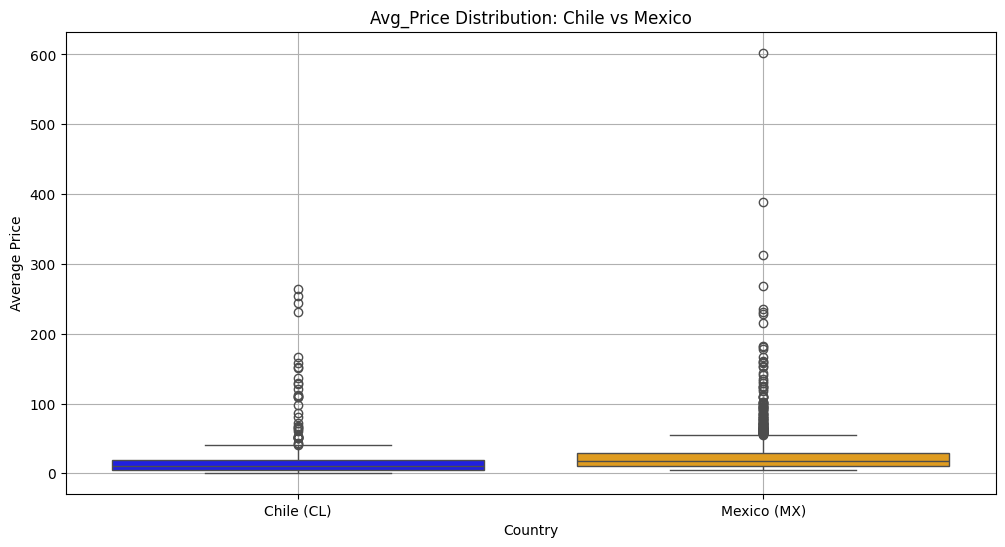

C:\Users\59680\AppData\Local\Temp\ipykernel_36636\1400377075.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y='Count', data=df_combined, palette=['blue', 'orange'])


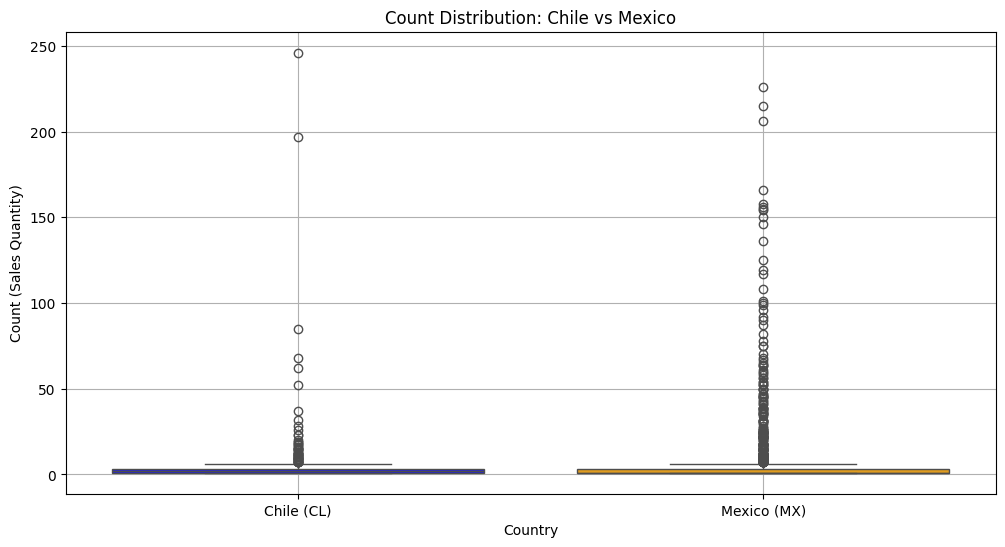

In [ ]:
# 合并两个国家的数据，添加国家标识
df_Sale_CL_ITE['Country'] = 'Chile (CL)'
df_Sale_MX_ITE['Country'] = 'Mexico (MX)'
df_combined = pd.concat([df_Sale_CL_ITE, df_Sale_MX_ITE])

# 绘制 Avg_Price 的箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='Avg_Price', data=df_combined, palette=['blue', 'orange'])
plt.title('Avg_Price Distribution: Chile vs Mexico')
plt.xlabel('Country')
plt.ylabel('Average Price')
plt.grid(True)
plt.savefig("CL_MX_avg_price_vs_count_boxplot.jpg")
plt.show()


In [ ]:
# 绘制 Avg_Price 的 KDE 图
plt.figure(figsize=(12, 6))
sns.kdeplot(df_Sale_CL_ITE['Avg_Price'], color='blue', label='Chile (CL)', fill=True)
sns.kdeplot(df_Sale_MX_ITE['Avg_Price'], color='orange', label='Mexico (MX)', fill=True)
plt.title('Avg_Price Distribution: Chile vs Mexico')
plt.xlabel('Average Price')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.savefig("CL_MX_avg_price_kde.jpg")
plt.show()

# 绘制 Count 的 KDE 图
plt.figure(figsize=(12, 6))
sns.kdeplot(df_Sale_CL_ITE['Count'], color='blue', label='Chile (CL)', fill=True)
sns.kdeplot(df_Sale_MX_ITE['Count'], color='orange', label='Mexico (MX)', fill=True)
plt.title('Count Distribution: Chile vs Mexico')
plt.xlabel('Count (Sales Quantity)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.savefig("CL_MX_count_kde.jpg")
plt.show()

In [226]:
import pandas as pd
# 合并两个表
merged = df_Sale_MX_ITE.merge(df_Sale_CL_ITE, on="ITE_ITEM_ID_PARENT_CBT", suffixes=("_CL", "_MX"))
# 计算差异
merged["Diff_Price"] = merged["Avg_Price_CL"] - merged["Avg_Price_MX"]
merged["Diff_Count"] = merged["Count_CL"] - merged["Count_MX"]
merged

,ITE_ITEM_ID_PARENT_CBT,GMV_CL,Avg_Price_CL,Count_CL,BID_MONTH_WIN_CL,ITE_ITEM_ID_CL,CAT_CATEG_ID_CL,GMV_MX,Avg_Price_MX,Count_MX,BID_MONTH_WIN_MX,ITE_ITEM_ID_MX,CAT_CATEG_ID_MX,Diff_Price,Diff_Count
0,920028571,52.62,26.310000,2.0,202008.0,697452728.0,103745.0,53.30,26.650000,2.0,202009.0,496670147.0,175495.0,-0.340000,0.0
1,920060933,11.01,11.010000,1.0,202008.0,697458726.0,172007.0,6.65,6.650000,1.0,202009.0,496679085.0,180894.0,4.360000,0.0
2,920070747,69.10,23.033333,3.0,202010.0,723857610.0,429016.0,31.85,31.850000,1.0,202009.0,496676724.0,429014.0,-8.816667,2.0
3,920072685,172.17,86.085000,2.0,202009.0,697490645.0,1009.0,302.48,60.496000,5.0,202010.0,496709965.0,1070.0,25.589000,-3.0
4,920078312,25.07,25.070000,1.0,202010.0,697527924.0,22575.0,10.17,10.170000,1.0,202009.0,496737066.0,45513.0,14.900000,0.0
5,920102546,22.17,22.170000,1.0,202008.0,697453170.0,1667.0,35.81,17.905000,2.0,202010.0,496670876.0,1667.0,4.265000,-1.0
6,920128427,18.30,9.150000,2.0,202009.0,702181200.0,1643.0,2.35,2.350000,1.0,202010.0,498688932.0,7175.0,6.800000,1.0
7,920129872,103.16,14.737143,7.0,202010.0,770213225.0,12191.0,10.14,5.070000,2.0,202008.0,499882121.0,409417.0,9.667143,5.0
8,920134443,14.26,7.130000,2.0,202009.0,712333564.0,1436.0,2.40,2.400000,1.0,202010.0,502828108.0,1436.0,4.730000,1.0
9,920136766,2892.92,38.572267,75.0,202010.0,723857479.0,126793.0,70.50,35.250000,2.0,202010.0,499263094.0,116538.0,3.322267,73.0


In [156]:
mx_sales = df_Sale[
    (df_Sale['CUS_CUST_ID_SEL'] == mx_seller_id)
]

# 计算GMV
mx_top_items = mx_sales.groupby('ITE_ITEM_ID').apply(
    lambda x: pd.Series({
        'GMV': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum(),
        'Avg_Price_MX': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum()/ (x['BID_QUANTITY_OK']).sum(),
        'Count': (x['BID_QUANTITY_OK']).sum()
        
    })
).nlargest(100, 'GMV').reset_index()

mx_top_items

C:\Users\59680\AppData\Local\Temp\ipykernel_36636\1377165190.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mx_top_items = mx_sales.groupby('ITE_ITEM_ID').apply(


,ITE_ITEM_ID,GMV,Avg_Price_MX,Count
0,733476754,9631.47,234.913902,41.0
1,702185475,1954.60,102.873684,19.0
2,705144779,1310.98,36.416111,36.0
3,771122641,1057.77,27.122308,39.0
4,697462554,1034.64,26.529231,39.0
...,...,...,...,...
95,801744092,106.87,35.623333,3.0
96,705134042,106.79,17.798333,6.0
97,705138347,106.03,17.671667,6.0
98,697464763,104.30,52.150000,2.0


In [157]:
merged_items = pd.merge(
    mx_top_items,
    df_Item[['ITE_ITEM_ID', 'SIT_SITE_ID', 'ITE_ITEM_ID_PARENT_CBT', 'ITE_STATUS']],
    on=['ITE_ITEM_ID'],
    how='left'
)
merged_items

,ITE_ITEM_ID,GMV,Avg_Price_MX,Count,SIT_SITE_ID,ITE_ITEM_ID_PARENT_CBT,ITE_STATUS
0,733476754,9631.47,234.913902,41.0,MLM,920139811,active
1,702185475,1954.60,102.873684,19.0,MLM,920162644,paused
2,705144779,1310.98,36.416111,36.0,MLM,920134059,active
3,771122641,1057.77,27.122308,39.0,MLM,920180659,active
4,697462554,1034.64,26.529231,39.0,MLM,920063650,active
...,...,...,...,...,...,...,...
95,801744092,106.87,35.623333,3.0,MLM,945173452,active
96,705134042,106.79,17.798333,6.0,MLM,920140194,active
97,705138347,106.03,17.671667,6.0,MLM,920119455,paused
98,697464763,104.30,52.150000,2.0,MLM,920056945,active


In [158]:
cl_items = df_Item[
    (df_Item['SIT_SITE_ID'] == 'MLC   ')
]
cl_items

,ITE_ITEM_ID,SIT_SITE_ID,CUS_CUST_ID,DATE_CREATED,CUS_CUST_ID_PARENT_CBT,ITE_STATUS,ITE_ITEM_ID_PARENT_CBT
7,496758685,MLC,435860518,2020/4/26,509685015,paused,920179979
16,514604862,MLC,435860518,2020/4/26,509685015,paused,920203030
18,521071925,MLC,435860518,2020/4/26,509685015,paused,920173654
19,496669813,MLC,435860518,2020/4/26,509685015,paused,920054129
20,518703725,MLC,435860518,2020/4/26,509685015,paused,920180343
...,...,...,...,...,...,...,...
283621,515951380,MLC,435860518,2020/4/26,509685015,active,920160259
283624,496646047,MLC,435860518,2020/4/26,509685015,paused,920021161
283627,497842920,MLC,435860518,2020/4/26,509685015,paused,920126688
283628,497725070,MLC,435860518,2020/4/26,509685015,paused,920114134


In [159]:
# (3) 检查智利上架状态
merged_items['Active_In_Chile'] = merged_items['ITE_ITEM_ID_PARENT_CBT'].isin(
    cl_items['ITE_ITEM_ID_PARENT_CBT']
).astype(int)

merged_items

,ITE_ITEM_ID,GMV,Avg_Price_MX,Count,SIT_SITE_ID,ITE_ITEM_ID_PARENT_CBT,ITE_STATUS,Active_In_Chile
0,733476754,9631.47,234.913902,41.0,MLM,920139811,active,1
1,702185475,1954.60,102.873684,19.0,MLM,920162644,paused,1
2,705144779,1310.98,36.416111,36.0,MLM,920134059,active,1
3,771122641,1057.77,27.122308,39.0,MLM,920180659,active,0
4,697462554,1034.64,26.529231,39.0,MLM,920063650,active,1
...,...,...,...,...,...,...,...,...
95,801744092,106.87,35.623333,3.0,MLM,945173452,active,1
96,705134042,106.79,17.798333,6.0,MLM,920140194,active,1
97,705138347,106.03,17.671667,6.0,MLM,920119455,paused,1
98,697464763,104.30,52.150000,2.0,MLM,920056945,active,0


In [160]:

# (3) 检查智利上架状态
cl_items = df_Item[
    (df_Item['SIT_SITE_ID'] == 'MLC   ') & 
    (df_Item['ITE_STATUS'] == 'active')
][['ITE_ITEM_ID_PARENT_CBT']].drop_duplicates()

merged_items['Active_In_Chile'] = merged_items['ITE_ITEM_ID_PARENT_CBT'].isin(
    cl_items['ITE_ITEM_ID_PARENT_CBT']
).astype(int)

# (4) 获取智利最新价格
cl_prices = df_Sale[
    (df_Sale['SIT_SITE_ID'] == 'MLC   ') & 
    (df_Sale['CUS_CUST_ID_SEL'] == cl_seller_id)
].sort_values('TIM_DAY_WINNING_DATE').groupby('ITE_ITEM_ID').last()[['ITE_ITEM_ID_PARENT_CBT','BID_BASE_CURRENT_PRICE']].reset_index()

# (5) 最终合并
final_df = pd.merge(
    merged_items,
    cl_prices[["ITE_ITEM_ID_PARENT_CBT","BID_BASE_CURRENT_PRICE"]],
    left_on='ITE_ITEM_ID_PARENT_CBT',
    right_on='ITE_ITEM_ID_PARENT_CBT',
    how='left',
    # suffixes=('', '_CL')
).rename(columns={'BID_BASE_CURRENT_PRICE': 'Current_Price_CL'})


In [161]:
final_df

,ITE_ITEM_ID,GMV,Avg_Price_MX,Count,SIT_SITE_ID,ITE_ITEM_ID_PARENT_CBT,ITE_STATUS,Active_In_Chile,Current_Price_CL
0,733476754,9631.47,234.913902,41.0,MLM,920139811,active,1,255.1
1,702185475,1954.60,102.873684,19.0,MLM,920162644,paused,0,NaN
2,705144779,1310.98,36.416111,36.0,MLM,920134059,active,1,NaN
3,771122641,1057.77,27.122308,39.0,MLM,920180659,active,0,NaN
4,697462554,1034.64,26.529231,39.0,MLM,920063650,active,0,NaN
...,...,...,...,...,...,...,...,...,...
95,801744092,106.87,35.623333,3.0,MLM,945173452,active,1,NaN
96,705134042,106.79,17.798333,6.0,MLM,920140194,active,0,NaN
97,705138347,106.03,17.671667,6.0,MLM,920119455,paused,0,NaN
98,697464763,104.30,52.150000,2.0,MLM,920056945,active,0,NaN


In [162]:
final_df

,ITE_ITEM_ID,GMV,Avg_Price_MX,Count,SIT_SITE_ID,ITE_ITEM_ID_PARENT_CBT,ITE_STATUS,Active_In_Chile,Current_Price_CL
0,733476754,9631.47,234.913902,41.0,MLM,920139811,active,1,255.1
1,702185475,1954.60,102.873684,19.0,MLM,920162644,paused,0,NaN
2,705144779,1310.98,36.416111,36.0,MLM,920134059,active,1,NaN
3,771122641,1057.77,27.122308,39.0,MLM,920180659,active,0,NaN
4,697462554,1034.64,26.529231,39.0,MLM,920063650,active,0,NaN
...,...,...,...,...,...,...,...,...,...
95,801744092,106.87,35.623333,3.0,MLM,945173452,active,1,NaN
96,705134042,106.79,17.798333,6.0,MLM,920140194,active,0,NaN
97,705138347,106.03,17.671667,6.0,MLM,920119455,paused,0,NaN
98,697464763,104.30,52.150000,2.0,MLM,920056945,active,0,NaN


In [163]:
import pandas as pd

# 假设已加载三个DataFrame
df_User = pd.read_csv("1.csv")  # 用户表（EXCEL4）
df_Item = pd.read_csv("2.csv")  # 商品表（EXCEL3）
df_Sale = pd.read_csv("3.csv")  # 销售表（EXCEL2）

# 预处理 ---------------
# 获取Manufacturer INC的卖家ID
mx_seller_id = df_User[df_User['Seller Name'] == 'Manufacturer INC. Mexico']['CUS_CUST_ID'].values[0]
cl_seller_id = df_User[df_User['Seller Name'] == 'Manufacturer INC. Chile']['CUS_CUST_ID'].values[0]

# 核心逻辑 ---------------
def analyze_sales():
    # (1) 获取墨西哥Top100商品
    mx_sales = df_Sale[
        (df_Sale['CUS_CUST_ID_SEL'] == mx_seller_id)
    ]
    
    # 计算GMV
    mx_top_items = mx_sales.groupby('ITE_ITEM_ID').apply(
        lambda x: pd.Series({
            'GMV': (x['BID_BASE_CURRENT_PRICE'] * x['BID_QUANTITY_OK']).sum(),
            'Avg_Price_MX': x['BID_BASE_CURRENT_PRICE'].mean()
        })
    ).nlargest(100, 'GMV').reset_index()

    # (2) 关联商品信息
    merged_items = pd.merge(
        mx_top_items,
        df_Item[['ITE_ITEM_ID', 'SIT_SITE_ID', 'ITE_ITEM_ID_PARENT_CBT', 'ITE_STATUS']],
        on=['ITE_ITEM_ID', 'SIT_SITE_ID'],
        how='left'
    )

    # (3) 检查智利上架状态
    cl_items = df_Item[
        (df_Item['SIT_SITE_ID'] == 'MLC') & 
        (df_Item['ITE_STATUS'] == 'active')
    ][['ITE_ITEM_ID_PARENT_CBT']].drop_duplicates()

    merged_items['Active_In_Chile'] = merged_items['ITE_ITEM_ID_PARENT_CBT'].isin(
        cl_items['ITE_ITEM_ID_PARENT_CBT']
    ).astype(int)

    # (4) 获取智利最新价格
    cl_prices = df_Sale[
        (df_Sale['SIT_SITE_ID'] == 'MLC') & 
        (df_Sale['CUS_CUST_ID_SEL'] == cl_seller_id)
    ].sort_values('TIM_DAY_WINNING_DATE').groupby('ITE_ITEM_ID').last()['BID_BASE_CURRENT_PRICE'].reset_index()

    # (5) 最终合并
    final_df = pd.merge(
        merged_items,
        cl_prices,
        left_on='ITE_ITEM_ID_PARENT_CBT',
        right_on='ITE_ITEM_ID',
        how='left',
        suffixes=('', '_CL')
    ).rename(columns={'BID_BASE_CURRENT_PRICE': 'Current_Price_CL'})

    return final_df[['ITE_ITEM_ID', 'GMV', 'Active_In_Chile', 'Avg_Price_MX', 'Current_Price_CL']]

# 执行分析
result_df = analyze_sales()
print(result_df.head(10))

C:\Users\59680\AppData\Local\Temp\ipykernel_36636\2452063571.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mx_top_items = mx_sales.groupby('ITE_ITEM_ID').apply(


KeyError: 'SIT_SITE_ID'

In [176]:
import pandas as pd

sellers  =pd.read_csv("1.csv")
items  =pd.read_csv("2.csv")
sales  =pd.read_csv("3.csv")

# sales = pd.merge(sales,items[["ITE_ITEM_ID","ITE_ITEM_ID_PARENT_CBT"]])
sales

,BID_MONTH_WIN,SIT_SITE_ID,ITE_ITEM_ID,TIM_DAY_WINNING_DATE,CUS_CUST_ID_SEL,CAT_CATEG_ID,BID_BASE_CURRENT_PRICE,BID_QUANTITY_OK,ORD_ORDER_ID,ITE_SHIPPING_MODE_ID
0,202008,MLB,1507897050,2020/8/4,435860284,73364,20.35,1,2.610427e+09,me1
1,202008,MLB,1507897050,2020/8/12,435860284,73364,23.29,1,2.628831e+09,me1
2,202008,MLB,1507897050,2020/8/1,435860284,73364,20.43,1,2.604974e+09,me1
3,202008,MLB,1396034502,2020/8/11,435860284,7457,23.79,1,2.624761e+09,me1
4,202008,MLB,1507897050,2020/8/14,435860284,73364,23.02,1,2.633171e+09,me1
...,...,...,...,...,...,...,...,...,...,...
26264,202008,MLC,542347143,2020/8/31,435860518,416771,12.49,1,4.014934e+09,me1
26265,202010,MLM,723857586,2020/10/14,459687369,7857,71.68,1,4.096872e+09,me2
26266,202009,MLM,750120443,2020/9/14,435857820,9883,22.61,1,4.038990e+09,me1
26267,202010,MLB,1311106209,2020/10/27,435860284,108704,20.14,1,4.121835e+09,me1


In [178]:

# 关联数据
merged = sales.merge(
    items[['ITE_ITEM_ID','SIT_SITE_ID','ITE_ITEM_ID_PARENT_CBT','ITE_STATUS']],
    on=['ITE_ITEM_ID','SIT_SITE_ID']
).merge(
    sellers,
    left_on='CUS_CUST_ID_SEL',
    right_on='CUS_CUST_ID'
)

# 筛选制造商数据
manufacturer_sales = merged[merged['Seller Name'].str.contains('Manufacturer INC')]

# 按国家-商品分组
analysis = manufacturer_sales.groupby(['SIT_SITE_ID','ITE_ITEM_ID_PARENT_CBT']).agg(
    avg_price=('BID_BASE_CURRENT_PRICE', 'mean'),
    total_sales=('BID_QUANTITY_OK', 'sum')
).reset_index()

# 透视比较
pivot_df = analysis.pivot(
    index='ITE_ITEM_ID_PARENT_CBT',
    columns='SIT_SITE_ID',
    values=['avg_price','total_sales']
)

# 计算差异
pivot_df['price_diff'] = pivot_df[('avg_price','MLC   ')] - pivot_df[('avg_price','MLM   ')]
pivot_df['sales_diff'] = pivot_df[('total_sales','MLC   ')] - pivot_df[('total_sales','MLM   ')]

# 相关性分析
correlation = pivot_df[['price_diff','sales_diff']].corr()
print(f"价格差异与销量差异的相关系数: {correlation.iloc[0,1]:.2f}")

价格差异与销量差异的相关系数: -0.26


In [180]:
analysis

,SIT_SITE_ID,ITE_ITEM_ID_PARENT_CBT,avg_price,total_sales
0,MLC,919998458,7.280,5
1,MLC,919998703,6.620,1
2,MLC,920012806,6.380,1
3,MLC,920013141,243.900,1
4,MLC,920017206,1.665,6
...,...,...,...,...
1560,MLM,952966145,16.720,3
1561,MLM,956109242,59.760,1
1562,MLM,956361138,42.520,1
1563,MLM,957040352,29.720,1
